# ETDRK4–Chebyshev solver for the generalized Burgers–Huxley equation

**Ready-to-run companion notebook** for

> *ETDRK4–Chebyshev Collocation for the Generalized Burgers–Huxley Equation:
> Machine-Precision Benchmarks and a Corrected Exact Solution.*

Run the cells top to bottom (`Kernel → Restart & Run All`). It reproduces the
paper's three headline results and lets you sweep parameters interactively:

1. **Machine precision** on the Ismail–Raslan–Rabboh benchmark with as few as
   `N = 2` collocation points and a single ETDRK4 step.
2. The **Wang gap** — a constant $3.748\times10^{-7}$ residual that appears when
   the scheme is benchmarked against the *erroneous* Wang–Zhu–Lu (1990) wave
   speed instead of the *corrected* Deng (2008) wave speed.
3. **Convergence** to round-off against the corrected solution.

The solver is embedded below so the notebook is self-contained; the production
module used for the paper's tightest benchmarks lives in `../src/`.

Requirements: `numpy`, `scipy` (optional), `matplotlib`.


In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

DENG = "#0072B2"   # blue       -> corrected (Deng 2008)
WANG = "#D55E00"   # vermillion -> erroneous (Wang-Zhu-Lu 1990)
mpl.rcParams.update({
    "font.size": 13, "axes.labelsize": 15, "axes.titlesize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.grid": True, "grid.alpha": 0.35, "grid.linestyle": "--",
    "lines.linewidth": 2.0, "figure.dpi": 110,
})

## 1. The solver

Chebyshev–Gauss–Lobatto collocation in space, Cox–Matthews / Kassam–Trefethen
ETDRK4 in time, with a linear boundary lift for the non-homogeneous Dirichlet
data. The matrix $\varphi$-functions are evaluated by diagonalising the (small,
dense) interior Laplacian.

In [2]:
def cheb(N, xmin=0.0, xmax=1.0):
    '''Chebyshev-Gauss-Lobatto nodes on [xmin,xmax] and 1st-derivative matrix.'''
    if N == 0:
        return np.array([xmax]), np.zeros((1, 1))
    k = np.arange(N + 1)
    xc = np.cos(np.pi * k / N)
    c = np.hstack([2.0, np.ones(N - 1), 2.0]) * (-1) ** k
    X = np.tile(xc, (N + 1, 1)).T
    dX = X - X.T
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))
    D = D - np.diag(D.sum(axis=1))
    x = xmin + (xmax - xmin) * (xc + 1) / 2.0
    return x, D * (2.0 / (xmax - xmin))


def _etd_coeffs(z, h):
    '''ETDRK4 scalar coefficient functions with Taylor guard near z=0.'''
    z = np.asarray(z, dtype=complex)
    small = np.abs(z) < 1e-3
    zs = np.where(small, 1.0, z)
    ez = np.exp(zs)
    Q  = h * (np.exp(zs / 2) - 1) / zs
    f1 = h * (-4 - zs + ez * (4 - 3 * zs + zs**2)) / zs**3
    f2 = h * (2 + zs + ez * (-2 + zs)) / zs**3
    f3 = h * (-4 - 3 * zs - zs**2 + ez * (4 - zs)) / zs**3
    Qs   = h * (1/2 + z/8 + z**2/48 + z**3/384)
    f1s  = h * (1/6 + z/6 + 3*z**2/40 + z**3/45)
    f23s = h * (1/6 + z/12 + z**2/40 + z**3/180)
    Q  = np.where(small, Qs,   Q)
    f1 = np.where(small, f1s,  f1)
    f2 = np.where(small, f23s, f2)
    f3 = np.where(small, f23s, f3)
    return Q, f1, f2, f3


def _matfun(L, h):
    A = h * L
    w, V = np.linalg.eig(A)
    Vi = np.linalg.inv(V)
    E  = (V * np.exp(w))     @ Vi
    E2 = (V * np.exp(w / 2)) @ Vi
    Q, f1, f2, f3 = _etd_coeffs(w, h)
    out = [E, E2, (V*Q)@Vi, (V*f1)@Vi, (V*f2)@Vi, (V*f3)@Vi]
    return [M.real if np.allclose(M.imag, 0, atol=1e-10) else M for M in out]


class GBHEtdrk4:
    '''u_t + alpha u^d u_x - eps u_xx = beta u (1-u^d)(u^d-gamma).'''

    def __init__(self, alpha, beta, gamma, delta, N, xmin, xmax,
                 initial_condition, gL, gR, exact_solution=None, eps=1.0):
        self.alpha, self.beta, self.gamma, self.delta, self.eps = alpha, beta, gamma, delta, eps
        self.gL, self.gR, self.exact = gL, gR, exact_solution
        self.x, self.D = cheb(N, xmin, xmax)
        self.D2 = self.D @ self.D
        self.N = N
        self.u0 = initial_condition(self.x)
        self.iI = np.arange(1, N)
        self.L = eps * self.D2[np.ix_(self.iI, self.iI)]

    def _N(self, uI, t):
        a, b, g, d, eps = self.alpha, self.beta, self.gamma, self.delta, self.eps
        u = np.empty(self.N + 1)
        u[self.iI] = uI
        u[0], u[-1] = self.gR(t), self.gL(t)
        ux, uxx = self.D @ u, self.D2 @ u
        rhs = -a * u**d * ux + b * u * (1 - u**d) * (u**d - g) + eps * uxx
        return rhs[self.iI] - self.L @ uI

    def solve(self, T, dt):
        h = dt
        E, E2, Q, f1, f2, f3 = _matfun(self.L, h)
        uI = self.u0[self.iI].copy()
        t = 0.0
        for _ in range(int(round(T / dt))):
            Nu = self._N(uI, t)
            a  = E2 @ uI + Q @ Nu;            Na = self._N(a, t + h/2)
            b  = E2 @ uI + Q @ Na;            Nb = self._N(b, t + h/2)
            c  = E2 @ a  + Q @ (2*Nb - Nu);   Nc = self._N(c, t + h)
            uI = E @ uI + f1 @ Nu + 2*f2 @ (Na + Nb) + f3 @ Nc
            t += h
        u = np.empty(self.N + 1)
        u[self.iI] = uI
        u[0], u[-1] = self.gR(t), self.gL(t)
        return u, t

    def linf_error(self, u, t):
        return np.max(np.abs(u - self.exact(self.x, t)))


def make_benchmark(alpha, beta, gamma, delta):
    '''Returns (u_exact, u0, A1, A2_corrected, A2_wang).'''
    s = np.sqrt(alpha**2 + 4*beta*(1 + delta))
    A1  = ((-delta*alpha + delta*s) * gamma) / (4*(1 + delta))
    A2  = (alpha*gamma)/(1+delta) + ((1+delta-gamma)*(alpha + s))/(2*(1+delta))   # Deng (corrected)
    A2W = (alpha*gamma)/(1+delta) - ((1+delta-gamma)*(-alpha + s))/(2*(1+delta))  # Wang (erroneous)
    u_exact = lambda x, t: (gamma/2 + (gamma/2)*np.tanh(A1*(x - A2*t)))**(1/delta)
    u0 = lambda x: u_exact(x, 0.0)
    return u_exact, u0, A1, A2, A2W

print("solver loaded")

solver loaded


## 2. Machine precision at the Ismail benchmark

$\alpha=\beta=\delta=1,\ \gamma=10^{-3}$. Even with **3 spatial points** ($N=2$)
and a **single** ETDRK4 step of size $\Delta t = 1$, the $L^\infty$ error sits at
floating-point round-off.

In [3]:
a, b, g, d = 1.0, 1.0, 1e-3, 1.0
u_exact, u0, A1, A2, A2W = make_benchmark(a, b, g, d)
gL = lambda t: u_exact(np.array([0.0]), t)[0]
gR = lambda t: u_exact(np.array([1.0]), t)[0]

print(f"A1 = {A1:.6e}   A2 (Deng, corrected) = {A2:.6f}   A2 (Wang) = {A2W:.6f}\n")
for N, dt, T in [(2, 1.0, 1.0), (20, 1e-2, 1.0), (20, 1e-2, 10.0)]:
    s = GBHEtdrk4(a, b, g, d, N, 0.0, 1.0, u0, gL, gR, u_exact)
    u, t = s.solve(T, dt)
    print(f"N={N:3d}  dt={dt:<5g}  t={T:<4g}  ->  Linf = {s.linf_error(u, t):.3e}")

A1 = 2.500000e-04   A2 (Deng, corrected) = 1.999500   A2 (Wang) = -0.999000

N=  2  dt=1      t=1     ->  Linf = 1.429e-15
N= 20  dt=0.01   t=1     ->  Linf = 3.597e-15
N= 20  dt=0.01   t=10    ->  Linf = 3.580e-15


## 3. The Wang-gap diagnostic

The corrected (Deng) and erroneous (Wang) wave speeds differ. Their travelling
waves are therefore separated by a residual that, at this $\gamma$, is **constant
in $x$** and equal in closed form to
$$\tfrac{\gamma A_1}{2}\,\bigl|A_2 - A_2^{W}\bigr| \approx 3.748\times10^{-7}.$$
Any scheme benchmarked against the Wang solution can never report an error below
this floor, no matter how fine the grid.

numerical  max|u_Deng - u_Wang| = 3.748125e-07
closed form (g A1 / 2)|dA2|     = 3.748125e-07


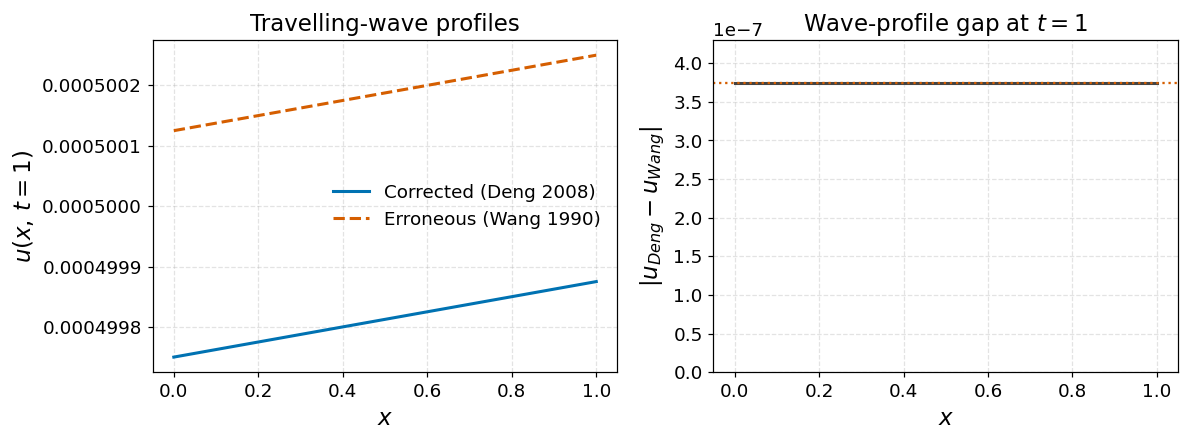

In [4]:
uW = lambda x, t: (g/2 + g/2*np.tanh(A1*(x - A2W*t)))**(1/d)
x = np.linspace(0, 1, 1000); t = 1.0
gap = np.abs(u_exact(x, t) - uW(x, t))
closed_form = (g * A1 / 2) * abs(A2 - A2W)
print(f"numerical  max|u_Deng - u_Wang| = {gap.max():.6e}")
print(f"closed form (g A1 / 2)|dA2|     = {closed_form:.6e}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(x, u_exact(x, t), color=DENG, label="Corrected (Deng 2008)")
ax[0].plot(x, uW(x, t), color=WANG, ls="--", label="Erroneous (Wang 1990)")
ax[0].set_xlabel("$x$"); ax[0].set_ylabel("$u(x,\\,t=1)$")
ax[0].set_title("Travelling-wave profiles"); ax[0].legend(frameon=False)
ax[1].plot(x, gap, color="#444444")
ax[1].axhline(3.748e-7, color=WANG, ls=":", lw=1.5)
ax[1].set_ylim(0, 4.3e-7)
ax[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useOffset=False)
ax[1].set_xlabel("$x$"); ax[1].set_ylabel("$|u_{Deng}-u_{Wang}|$")
ax[1].set_title("Wave-profile gap at $t=1$")
fig.tight_layout(); plt.show()

## 4. Convergence: round-off vs the Wang floor

The *same* numerical solution is compared against both exact solutions. Against
the corrected (Deng) wave it converges to round-off; against the erroneous
(Wang) wave it flatlines at the gap — visual proof that the floor is an artefact
of the wrong formula, not of the scheme.

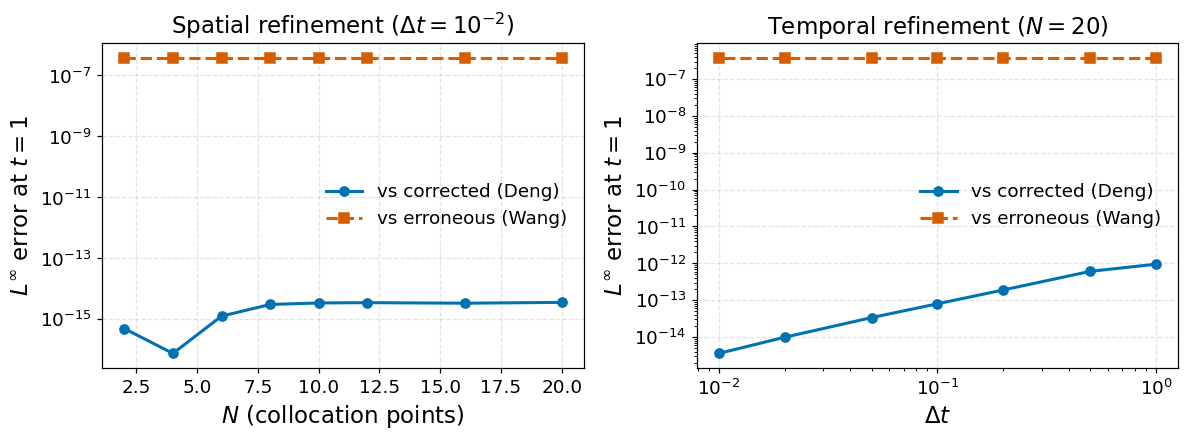

In [5]:
Ns = [2, 4, 6, 8, 10, 12, 16, 20]
eD_N = []; eW_N = []
for N in Ns:
    s = GBHEtdrk4(a, b, g, d, N, 0.0, 1.0, u0, gL, gR, u_exact)
    u, tt = s.solve(1.0, 1e-2)
    eD_N.append(np.max(np.abs(u - u_exact(s.x, tt))))
    eW_N.append(np.max(np.abs(u - uW(s.x, tt))))

dts = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01]
eD_dt = []; eW_dt = []
for dt in dts:
    s = GBHEtdrk4(a, b, g, d, 20, 0.0, 1.0, u0, gL, gR, u_exact)
    u, tt = s.solve(1.0, dt)
    eD_dt.append(np.max(np.abs(u - u_exact(s.x, tt))))
    eW_dt.append(np.max(np.abs(u - uW(s.x, tt))))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].semilogy(Ns, eD_N, "o-",  color=DENG, label="vs corrected (Deng)")
ax[0].semilogy(Ns, eW_N, "s--", color=WANG, label="vs erroneous (Wang)")
ax[0].set_xlabel("$N$ (collocation points)"); ax[0].set_ylabel("$L^\\infty$ error at $t=1$")
ax[0].set_title("Spatial refinement ($\\Delta t=10^{-2}$)"); ax[0].legend(frameon=False)
ax[1].loglog(dts, eD_dt, "o-",  color=DENG, label="vs corrected (Deng)")
ax[1].loglog(dts, eW_dt, "s--", color=WANG, label="vs erroneous (Wang)")
ax[1].set_xlabel("$\\Delta t$"); ax[1].set_ylabel("$L^\\infty$ error at $t=1$")
ax[1].set_title("Temporal refinement ($N=20$)"); ax[1].legend(frameon=False)
fig.tight_layout(); plt.show()

## 5. Try your own parameters

Change $\alpha,\beta,\gamma,\delta$ below and re-run. The $\delta=2$ (Hashim)
regime also reaches round-off.

In [6]:
def run_case(alpha, beta, gamma, delta, N=20, dt=1e-2, T=1.0):
    ue, ic, *_ = make_benchmark(alpha, beta, gamma, delta)
    gl = lambda t: ue(np.array([0.0]), t)[0]
    gr = lambda t: ue(np.array([1.0]), t)[0]
    s = GBHEtdrk4(alpha, beta, gamma, delta, N, 0.0, 1.0, ic, gl, gr, ue)
    u, t = s.solve(T, dt)
    return s.linf_error(u, t)

for (al, be, ga, de, lbl) in [
    (1.0, 1.0, 1e-3, 1.0, "Ismail   (delta=1)"),
    (1.0, 1.0, 1e-2, 2.0, "Hashim   (delta=2)"),
    (0.5, 1.0, 1e-3, 1.0, "alpha=0.5"),
]:
    print(f"{lbl:22s}  Linf = {run_case(al, be, ga, de):.3e}")

Ismail   (delta=1)      Linf = 3.597e-15
Hashim   (delta=2)      Linf = 5.035e-11
alpha=0.5               Linf = 1.830e-15
